<a href="https://colab.research.google.com/github/Bharathi8197/EDA_EXP_01/blob/main/Arch_Diagram.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 1 not upgraded.


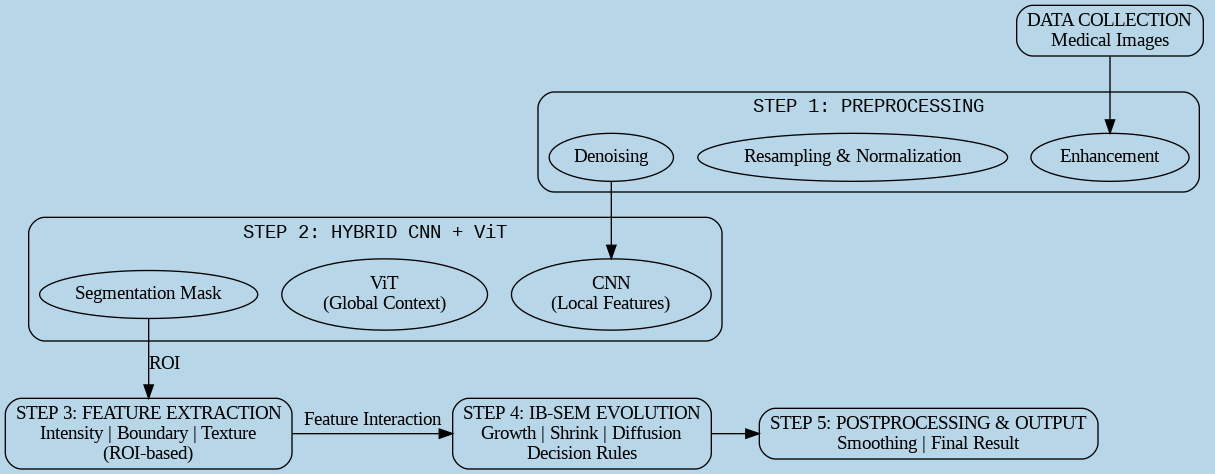

In [ ]:
!apt-get install graphviz -y
!pip install graphviz

from graphviz import Digraph
from IPython.display import Image, display

dot = Digraph(
    'Journal_Architecture_Final_v2',
    format='png',
    engine='dot'
)

dot.attr(
    bgcolor='#b7d7e8',
    fontname='Times New Roman'
)

# ---------------- DATA COLLECTION ----------------
dot.node(
    'Data',
    'DATA COLLECTION\nMedical Images',
    shape='box',
    style='rounded'
)

# ---------------- STEP 1: PREPROCESSING ----------------
with dot.subgraph(name='cluster_pre') as pre:
    pre.attr(label='STEP 1: PREPROCESSING',
             style='rounded')
    pre.node('Enh', 'Enhancement')
    pre.node('Norm', 'Resampling & Normalization')
    pre.node('Den', 'Denoising')

# ---------------- STEP 2: CNN + ViT ----------------
with dot.subgraph(name='cluster_model') as model:
    model.attr(label='STEP 2: HYBRID CNN + ViT',
               style='rounded')
    model.node('CNN', 'CNN\n(Local Features)')
    model.node('ViT', 'ViT\n(Global Context)')
    model.node('Mask', 'Segmentation Mask')

# ---------------- STEP 3: FEATURE EXTRACTION ----------------
dot.node(
    'Feat',
    'STEP 3: FEATURE EXTRACTION\nIntensity | Boundary | Texture\n(ROI-based)',
    shape='box',
    style='rounded'
)

# ---------------- STEP 4: IB-SEM ----------------
dot.node(
    'IBSEM',
    'STEP 4: IB-SEM EVOLUTION\nGrowth | Shrink | Diffusion\nDecision Rules',
    shape='box',
    style='rounded'
)

# ---------------- STEP 5: POSTPROCESSING ----------------
dot.node(
    'Post',
    'STEP 5: POSTPROCESSING & OUTPUT\nSmoothing | Final Result',
    shape='box',
    style='rounded'
)

# -------- FORCE STEP 3, 4, 5 ON SAME LEVEL --------
with dot.subgraph() as same_rank:
    same_rank.attr(rank='same')
    same_rank.node('Feat')
    same_rank.node('IBSEM')
    same_rank.node('Post')

# ---------------- CLEAN ARCHITECTURAL ARROWS ----------------
dot.edge('Data', 'Enh')
dot.edge('Den', 'CNN')
dot.edge('Mask', 'Feat', label='ROI')
dot.edge('Feat', 'IBSEM', label='Feature Interaction')
dot.edge('IBSEM', 'Post')

# Render
file_path = dot.render('journal_architecture_final_layout')
display(Image(filename=file_path))


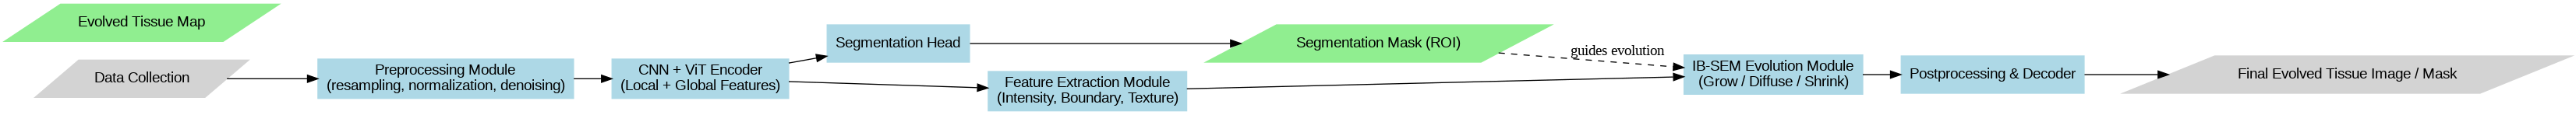

In [ ]:


Image('/content/tissue_evolution_architecture.png')
